# Анализ воронки интернет-магазина

## 1. Цель проекта

Цель — построить пользовательскую воронку, посмотреть динамику и проверить две продуктовые гипотезы на полном датасете Retailrocket.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.metrics import (
    build_user_funnel, build_user_table, calculate_daily_metrics,
    cart_to_purchase_times, group_conversion, summarize_funnel,
)
from src.processing import load_events, prepare_events

## 2. Загрузка данных

Загружаю только нужные столбцы. Если полного файла нет, загрузка завершится с инструкцией по скачиванию.

In [2]:
raw_events = load_events(project_root / 'data/raw/events.csv')
print(f'Строк до очистки: {len(raw_events):,}')
raw_events.head()

Строк до очистки: 2,756,101


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


## 3. Первичная проверка данных

Проверяю размер таблицы, типы, пропуски и количество полных дубликатов. Пустой `transactionid` у просмотра является нормальным.

In [3]:
raw_events.info()
display(raw_events.describe(include='all'))
display(raw_events.isna().sum().to_frame('Пропуски'))
print(f'Полных дубликатов: {raw_events.duplicated().sum():,}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


,Пропуски
timestamp,0
visitorid,0
event,0
itemid,0
transactionid,2733644


Полных дубликатов: 460


## 4. Очистка дубликатов

Удаляю полные дубликаты, перевожу timestamp в дату и время, затем сортирую события по пользователю и времени.

In [4]:
events = prepare_events(raw_events)
print(f'Строк после очистки: {len(events):,}')
print(f'Период: {events.event_time.min()} — {events.event_time.max()}')

Строк после очистки: 2,755,641
Период: 2015-05-03 03:00:04.384000 — 2015-09-18 02:59:47.788000


## 5. Количество событий и пользователей

Уникальных пользователей: 1,407,580


,Количество
event,
view,2664218
addtocart,68966
transaction,22457


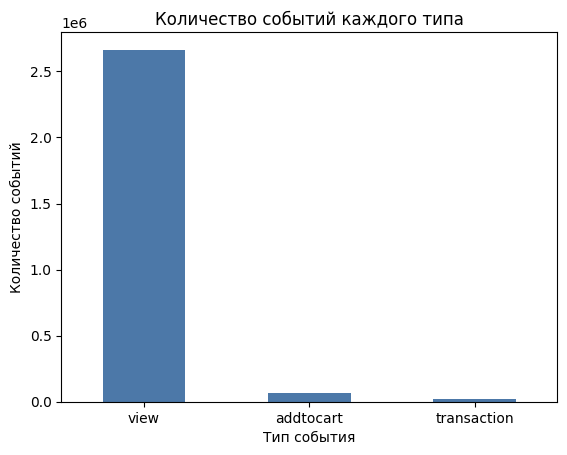

In [5]:
event_counts = events['event'].value_counts()
print(f"Уникальных пользователей: {events['visitorid'].nunique():,}")
display(event_counts.to_frame('Количество'))

event_counts.plot(kind='bar', color='#4C78A8')
plt.title('Количество событий каждого типа')
plt.xlabel('Тип события')
plt.ylabel('Количество событий')
plt.xticks(rotation=0)
plt.show()

## 6. Воронка

Для пользователя беру первый просмотр, первую корзину после просмотра и первую покупку после корзины.

In [6]:
user_funnel = build_user_funnel(events)
funnel = summarize_funnel(user_funnel)
funnel_table = pd.DataFrame({
    'Этап': ['Просмотр', 'Корзина', 'Покупка'],
    'Пользователи': [funnel['view_users'], funnel['cart_users'], funnel['transaction_users']],
    'Конверсия от просмотра, %': [100, funnel['view_to_cart'] * 100, funnel['view_to_transaction'] * 100],
})
display(funnel_table)
print(f"Конверсия из корзины в покупку: {funnel['cart_to_transaction']:.3%}")
print(f"Потери до корзины: {funnel['lost_before_cart']:,}")
print(f"Потери после корзины: {funnel['lost_before_transaction']:,}")

,Этап,Пользователи,"Конверсия от просмотра, %"
0,Просмотр,1404179,100.000000
1,Корзина,32934,2.345427
2,Покупка,9952,0.708742


Конверсия из корзины в покупку: 30.218%
Потери до корзины: 1,371,245
Потери после корзины: 22,982


Медианное время от корзины до покупки: 0.10 часа
Доля покупок в течение 24 часов: 95.549%


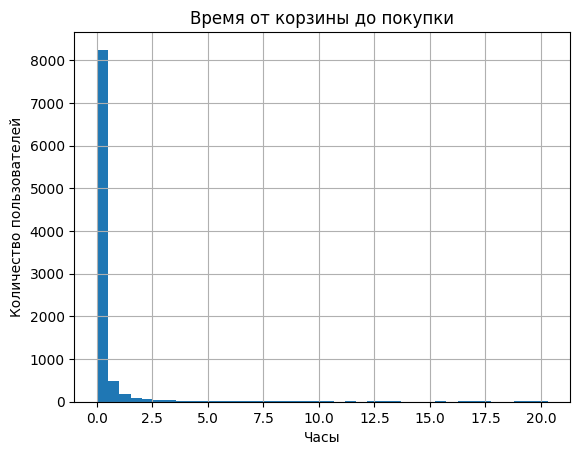

In [7]:
purchases, purchase_time = cart_to_purchase_times(user_funnel)
print(f"Медианное время от корзины до покупки: {purchase_time['median_hours']:.2f} часа")
print(f"Доля покупок в течение 24 часов: {purchase_time['within_24_hours']:.3%}")

limit = purchases['hours_to_purchase'].quantile(0.95)
purchases[purchases['hours_to_purchase'] <= limit]['hours_to_purchase'].hist(bins=40)
plt.title('Время от корзины до покупки')
plt.xlabel('Часы')
plt.ylabel('Количество пользователей')
plt.show()

## 7. Динамика по дням

Считаю активных пользователей, события и конверсию по дню первого просмотра.

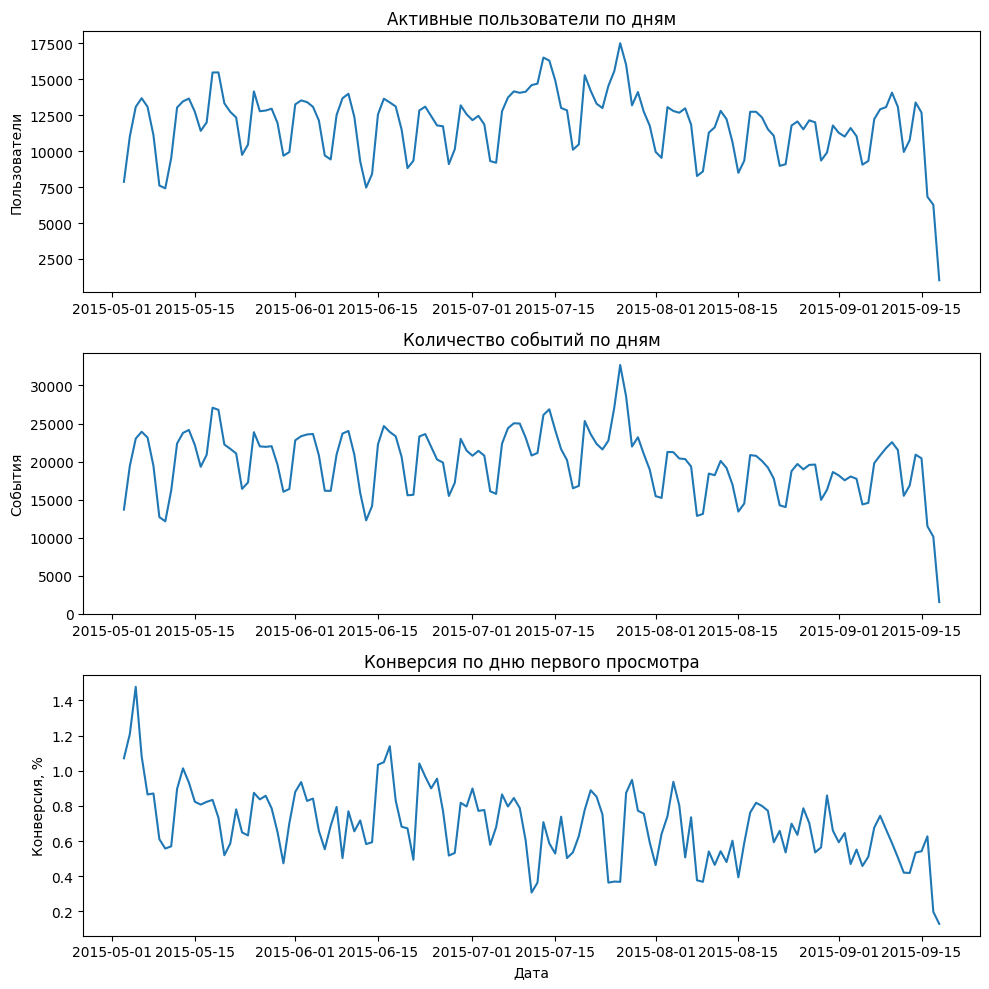

In [8]:
users = build_user_table(user_funnel)
daily = calculate_daily_metrics(events, users)
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(daily['event_date'], daily['active_users'])
axes[0].set_title('Активные пользователи по дням')
axes[0].set_ylabel('Пользователи')
axes[1].plot(daily['event_date'], daily['events'])
axes[1].set_title('Количество событий по дням')
axes[1].set_ylabel('События')
axes[2].plot(daily['event_date'], daily['conversion'] * 100)
axes[2].set_title('Конверсия по дню первого просмотра')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Конверсия, %')
plt.tight_layout()
plt.show()

## 8. Гипотеза про выходные

Гипотеза: пользователи, впервые пришедшие в выходные, конвертируются чаще, потому что у них может быть больше свободного времени.

Критерий хи-квадрат проверяет, связаны ли две категориальные переменные. В нашем случае — группа пользователя и факт покупки.

In [9]:
weekday = group_conversion(users, 'is_weekend')
weekday['Период'] = weekday['is_weekend'].map({False: 'Будни', True: 'Выходные'})
weekday['Конверсия, %'] = weekday['conversion'] * 100
display(weekday[['Период', 'users', 'buyers', 'Конверсия, %']])

table = pd.crosstab(users['is_weekend'], users['purchased'])
chi2, p_value, dof, expected = chi2_contingency(table)
print(f'Минимальная ожидаемая частота: {expected.min():.1f}')
print(f'Хи-квадрат: {chi2:.2f}')
print(f'p-value: {p_value:.2e}')

,Период,users,buyers,"Конверсия, %"
0,Будни,1066516,8078,0.757419
1,Выходные,337663,1874,0.554991


Минимальная ожидаемая частота: 2393.2
Хи-квадрат: 149.05
p-value: 2.80e-34


Конверсия в выходные ниже, чем в будни. Продуктовая гипотеза не подтвердилась. Тест показывает различие между группами, но направление оказалось противоположным ожиданию.

## 9. Гипотеза про вечер

Гипотеза: пользователи, впервые пришедшие вечером, конвертируются чаще, потому что вечером у них больше времени на выбор товара.

In [10]:
daypart = group_conversion(users, 'daypart')
daypart['Конверсия, %'] = daypart['conversion'] * 100
display(daypart[['daypart', 'users', 'buyers', 'Конверсия, %']])

table = pd.crosstab(users['daypart'], users['purchased'])
chi2, p_value, dof, expected = chi2_contingency(table)
print(f'Минимальная ожидаемая частота: {expected.min():.1f}')
print(f'Хи-квадрат: {chi2:.2f}')
print(f'p-value: {p_value:.2e}')

,daypart,users,buyers,"Конверсия, %"
0,Ночь,440608,2851,0.647060
1,Утро,109007,586,0.537580
2,День,323011,2533,0.784184
3,Вечер,531553,3982,0.749126


Минимальная ожидаемая частота: 772.6
Хи-квадрат: 107.64
p-value: 3.53e-23


Максимальная конверсия наблюдается днём, а не вечером. Гипотеза не подтвердилась. Критерий показывает общую связь времени первого просмотра и покупки, но не доказывает влияние времени суток.

## 10. Итоговые выводы

- Из просмотра в корзину перешли 2,345% пользователей.
- Из корзины в покупку перешли 30,218% пользователей.
- Общая конверсия из просмотра в покупку равна 0,709%.
- Обе направленные продуктовые гипотезы не подтвердились.

## 11. Ограничения

- Часовой пояс timestamp неизвестен.
- Воронка не связывает этапы по одному товару.
- Наблюдательные данные не доказывают причинность.
- У пользователей в конце датасета было меньше времени на покупку.
- Нет цены, канала привлечения и данных о наличии товара.